# Fashion-MNIST Classification

Goal: classify grayscale images of clothing items (shirts, shoes, slippers, etc.) into 10 categories, using the same approach as the digit-MNIST project — load data, normalize, build a Dense neural network, train it, evaluate it, and make predictions on new images.

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


## 1. Explore the data

Check the shapes, label range, and pixel value range before doing anything else.

In [2]:
print("train_images shape:", train_images.shape)
print("train_labels shape:", train_labels.shape)
print("test_images shape:", test_images.shape)
print("test_labels shape:", test_labels.shape)

print("Label range:", train_labels.min(), "to", train_labels.max())
print("Pixel range:", train_images.min(), "to", train_images.max())

train_images shape: (60000, 28, 28)
train_labels shape: (60000,)
test_images shape: (10000, 28, 28)
test_labels shape: (10000,)
Label range: 0 to 9
Pixel range: 0 to 255


Fashion-MNIST has 10 classes, each an integer 0-9:

| Label | Class |
|---|---|
| 0 | T-shirt/top |
| 1 | Trouser |
| 2 | Pullover |
| 3 | Dress |
| 4 | Coat |
| 5 | Sandal |
| 6 | Shirt |
| 7 | Sneaker |
| 8 | Bag |
| 9 | Ankle boot |

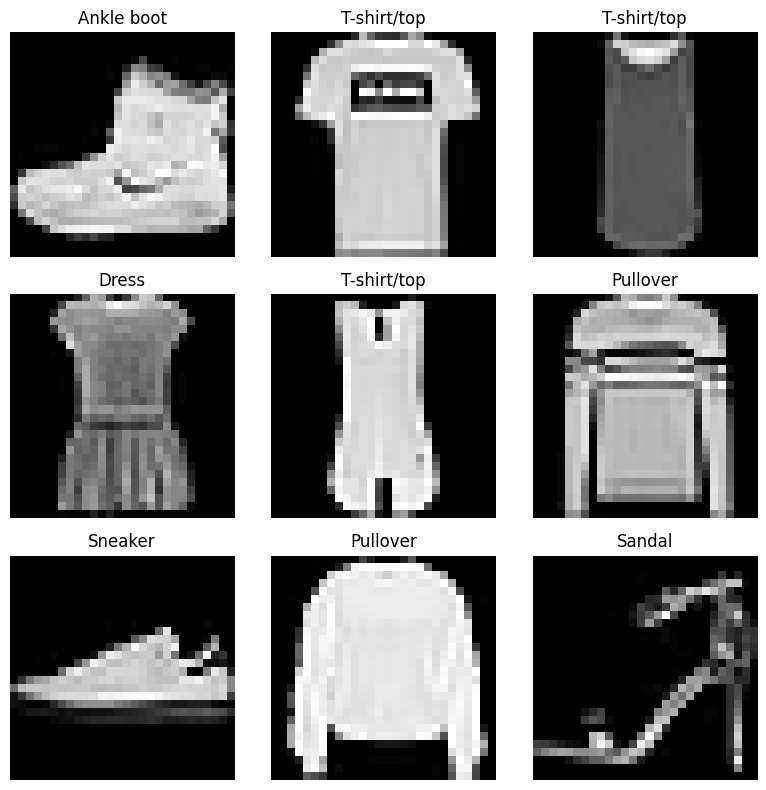

In [3]:
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

plt.figure(figsize=(8, 8))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(train_images[i], cmap="gray")
    plt.title(class_names[train_labels[i]])
    plt.axis("off")
plt.tight_layout()
plt.show()

## 2. Normalize the pixel values

Scale pixel values from the 0-255 range down to 0-1, same as the MNIST project. This helps the network train faster and more reliably.

In [4]:
train_images = train_images / 255.0
test_images = test_images / 255.0

## 3. Build the model

A simple Dense (fully-connected) network:
- `Flatten` turns each 28x28 image into a 784-length vector
- One hidden `Dense` layer with ReLU activation
- An output `Dense` layer with 10 units (one per class) and `softmax`, since this is multi-class classification

In [5]:
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

## 4. Compile the model

Labels are plain integers (0-9), not one-hot vectors, so we use `sparse_categorical_crossentropy` as the loss function.

In [6]:
model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

## 5. Train the model

Hold out 20% of the training data for validation, so we can watch for overfitting.

In [7]:
history = model.fit(train_images, train_labels,
                     epochs=15,
                     validation_split=0.2)

Epoch 1/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step - accuracy: 0.8185 - loss: 0.5184 - val_accuracy: 0.8558 - val_loss: 0.4099
Epoch 2/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8614 - loss: 0.3875 - val_accuracy: 0.8730 - val_loss: 0.3600
Epoch 3/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8727 - loss: 0.3467 - val_accuracy: 0.8682 - val_loss: 0.3580
Epoch 4/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8832 - loss: 0.3202 - val_accuracy: 0.8692 - val_loss: 0.3725
Epoch 5/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8884 - loss: 0.3026 - val_accuracy: 0.8801 - val_loss: 0.3284
Epoch 6/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8947 - loss: 0.2863 - val_accuracy: 0.8796 - val_loss: 0.3361
Epoch 7/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8979 - loss: 0.2720 - val_accuracy: 0.8816 - val_loss: 0.3208
Epoch 8/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9024 - loss: 0.2623 -

## 6. Plot training vs validation curves

If validation loss starts climbing while training loss keeps dropping, that's overfitting.

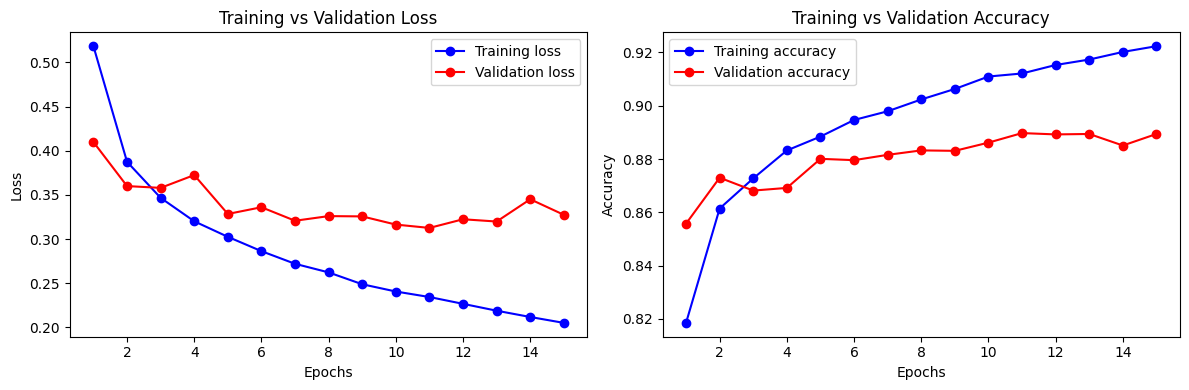

In [8]:
history_dict = history.history

loss = history_dict["loss"]
val_loss = history_dict["val_loss"]
acc = history_dict["accuracy"]
val_acc = history_dict["val_accuracy"]
epochs = range(1, len(loss) + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs, loss, "bo-", label="Training loss")
plt.plot(epochs, val_loss, "ro-", label="Validation loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, acc, "bo-", label="Training accuracy")
plt.plot(epochs, val_acc, "ro-", label="Validation accuracy")
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

## 7. Evaluate on the test set

In [9]:
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=2)
print("Test accuracy:", test_acc)

313/313 - 2s - 6ms/step - accuracy: 0.8863 - loss: 0.3564
Test accuracy: 0.8863000273704529


## 8. Make predictions

The assignment explicitly asks for predictions after training, not just accuracy. `model.predict` gives a probability distribution over the 10 classes for each image — `np.argmax` picks the most likely one.

In [10]:
predictions = model.predict(test_images)

print("Predicted probabilities for image 0:", predictions[0])
print("Predicted class:", np.argmax(predictions[0]), "->", class_names[np.argmax(predictions[0])])
print("Actual class:", test_labels[0], "->", class_names[test_labels[0]])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Predicted probabilities for image 0: [4.2268589e-09 1.7401780e-12 2.3987335e-08 1.6070932e-10 4.7391626e-12
 1.3323865e-05 2.2162370e-08 8.9353984e-03 1.3834239e-09 9.9105120e-01]
Predicted class: 9 -> Ankle boot
Actual class: 9 -> Ankle boot


## 9. Visualize some predictions

Green title = correct prediction, red title = wrong prediction.

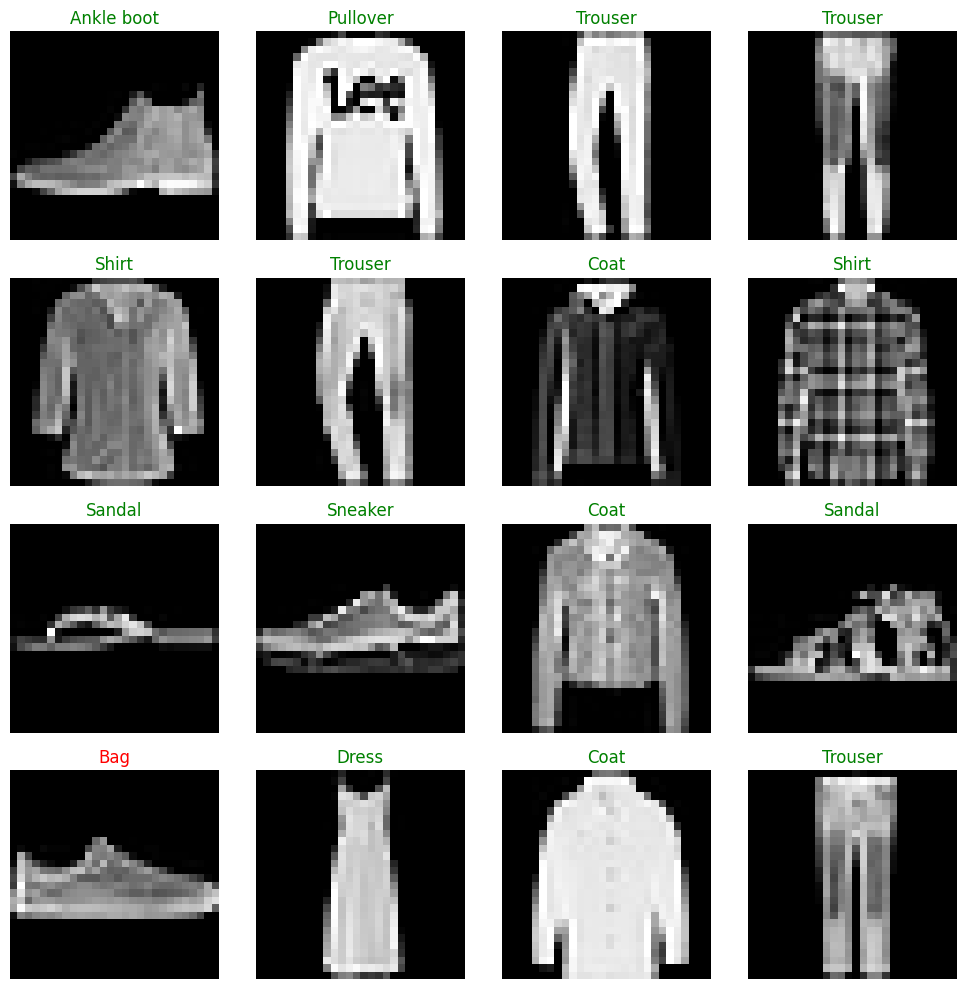

In [11]:
plt.figure(figsize=(10, 10))
for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow(test_images[i], cmap="gray")
    predicted_label = np.argmax(predictions[i])
    true_label = test_labels[i]
    color = "green" if predicted_label == true_label else "red"
    plt.title(f"{class_names[predicted_label]}", color=color)
    plt.axis("off")
plt.tight_layout()
plt.show()

## 10. Confusion matrix (optional but useful)

Shows which classes get mixed up with each other — commonly Shirt vs T-shirt vs Pullover vs Coat, since they look visually similar.

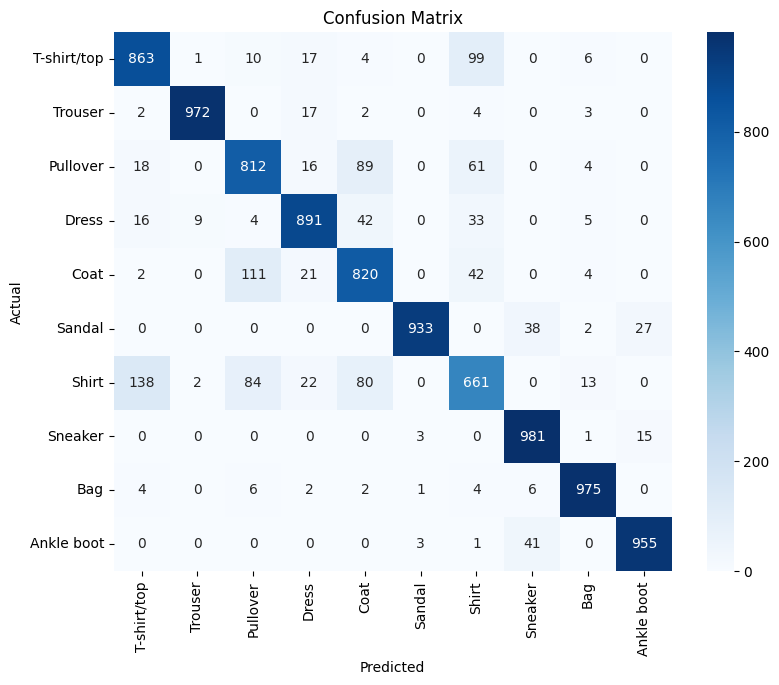

In [12]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

predicted_labels = np.argmax(predictions, axis=1)
cm = confusion_matrix(test_labels, predicted_labels)

plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()